# Spectral Pipeline — Figures

Vector, LaTeX-styled figures rendered **from precomputed data only** — this
notebook never runs an attack or a fit. Run the pipeline first
(`python run_pipeline.py --config config.yaml --stage all`), then execute this
notebook top to bottom.

Sections
1. Setup & style
2. Distribution plots (β, R², ΔAIC) — from the master descriptors
3. Radial occupation profiles (median curve + fit overlays) — from the `.npz`
4. Test A — descriptor evolution with budget
5. Test B — model validation / overfitting
6. Test C — anisotropy-index validation
7. Test D — saturation / clipping sanity

Every figure is written to `plots/figures/` as **both** `.pdf` and `.svg`
(vector) and shown inline.


## 1. Setup & style

In [1]:
import os, sys, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- where the pipeline wrote its results ---------------------------------
# notebook lives in plots/, outputs live one level up under `root` (default "outputs")
REPO = Path("..").resolve()
RESULTS_DIR = REPO / "outputs"          # <- change if your config `root` differs
N_IMAGES = 500                           # <- match config.n_images
ATTACKS = ["BIM", "PGD"]
EPS_VALUES = [2, 4, 8, 12, 16]           # /255

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
USE_TEX = False   # set True only if a LaTeX toolchain is installed

# reuse the exact model laws for fit overlays (no re-implementation)
sys.path.insert(0, str(REPO))
from spectral.core import fermi_dirac_E, maxwell_boltzmann_E, kww_glass_E

print("results dir:", RESULTS_DIR, "| exists:", RESULTS_DIR.exists())

results dir: /home/wiwi/Downloads/spectral_pipeline/outputs | exists: True


# ---- academic / LaTeX-style matplotlib theme ------------------------------
mpl.rcParams.update({
    "text.usetex": USE_TEX,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "lines.linewidth": 1.8,
    "figure.dpi": 120,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "figure.max_open_warning": 0,
})

In [2]:
# ---- academic / LaTeX-style matplotlib theme ------------------------------
mpl.rcParams.update({
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "lines.linewidth": 1.8,
    "figure.dpi": 120,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "figure.max_open_warning": 0,
})

# consistent palettes across the whole thesis
TYPE_COLORS  = {"clean": "#7F8C8D", "adv": "#C0392B", "perturbation": "#153E75"}
GROUP_COLORS = {"perturbation": "#153E75", "noise_sign": "#F39C12",
                "noise_gauss": "#2AA876", "noise_shuffle": "#8E44AD"}
MODEL_COLORS = {"fd": "#8E44AD", "mb": "#E67E22", "kww": "#153E75"}
MODEL_LABEL  = {"fd": "Fermi--Dirac", "mb": "Maxwell--Boltzmann", "kww": "KWW"}

def eps_label(e_pix):    return f"{int(round(e_pix*255))}/255"
def eps_ticks(vals):     return [eps_label(v) for v in vals]

def savefig(fig, name):
    for ext in ("pdf", "svg"):
        fig.savefig(FIGDIR / f"{name}.{ext}")
    print("saved", FIGDIR / f"{name}.pdf")

def _read(path):
    path = Path(path)
    if not path.exists():
        print(f"  [skip] missing: {path}")
        return None
    return pd.read_csv(path)

# canonical paths derived from the layout in config.py
P = {
    "master":  lambda a: RESULTS_DIR / "master" / f"{a}_master_aggRGB_{N_IMAGES}.csv",
    "radial":  lambda a: RESULTS_DIR / "master" / f"{a}_radial_profiles_{N_IMAGES}.npz",
    "A":       lambda a, tf, s: RESULTS_DIR / "A" / "results" / f"A_{a}_{tf}_{s}.csv",
    "B_sum":   RESULTS_DIR / "B" / "results" / "per_eps_model_comparison_summary.csv",
    "B_cons":  RESULTS_DIR / "B" / "results" / "consistency_overfit_table.csv",
    "C_sum":   lambda a: RESULTS_DIR / "C" / "results" / f"AI_v2_summary_by_eps_group_{a}.csv",
    "C_cmp":   lambda a: RESULTS_DIR / "C" / "results" / f"AI_v2_perturbation_vs_controls_{a}.csv",
    "C_pair":  lambda a: RESULTS_DIR / "C" / "results" / f"AI_v2_paired_shuffle_summary_{a}.csv",
    "C_mono":  lambda a: RESULTS_DIR / "C" / "results" / f"AI_v2_monotonicity_summary_{a}.csv",
    "D_sum":   RESULTS_DIR / "D" / "results" / "perturbation_only_summary_by_eps.csv",
    "D_pm":    lambda m: RESULTS_DIR / "D" / "results" / f"perturbation_only_profile_mode_{m}.csv",
}
print("style ready")

style ready


## 2. Distribution plots

Histograms of the descriptors that carry the thesis' signal, split by sample
type. From the master RGB-median descriptors.

saved figures/dist_beta_BIM.pdf


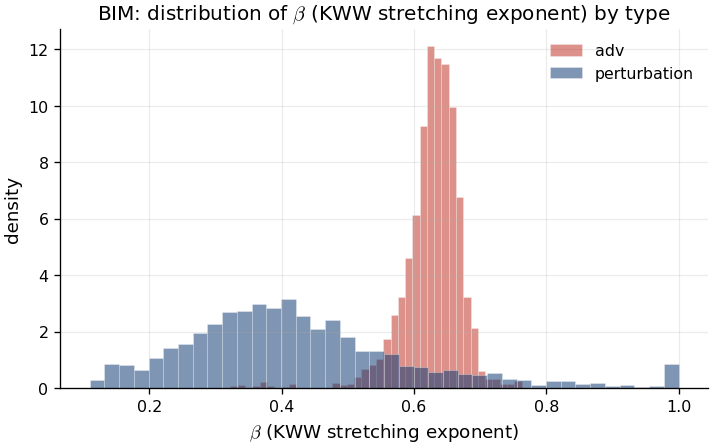

saved figures/dist_R2_BIM_perturbation.pdf


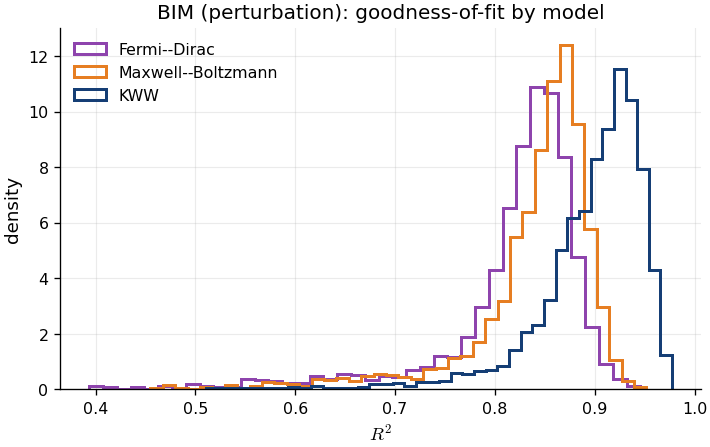

saved figures/dist_dAIC_kww_mb_BIM.pdf


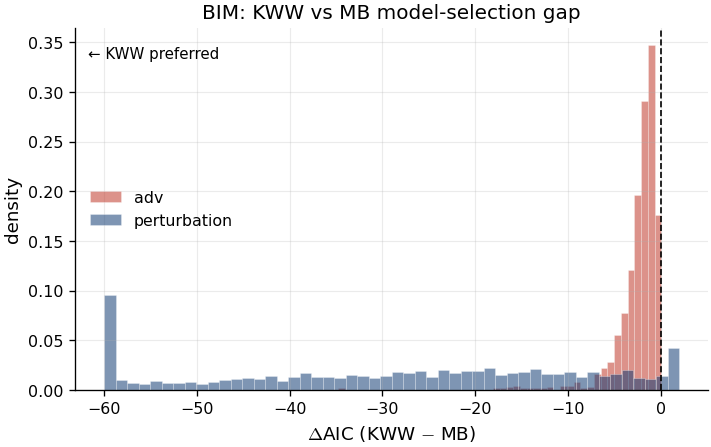

saved figures/dist_beta_PGD.pdf


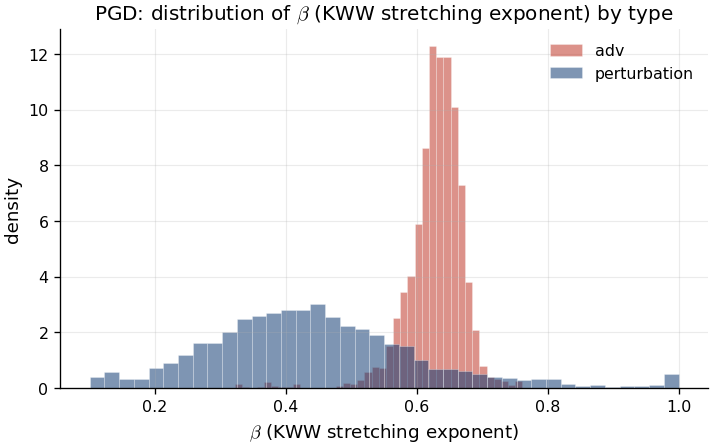

saved figures/dist_R2_PGD_perturbation.pdf


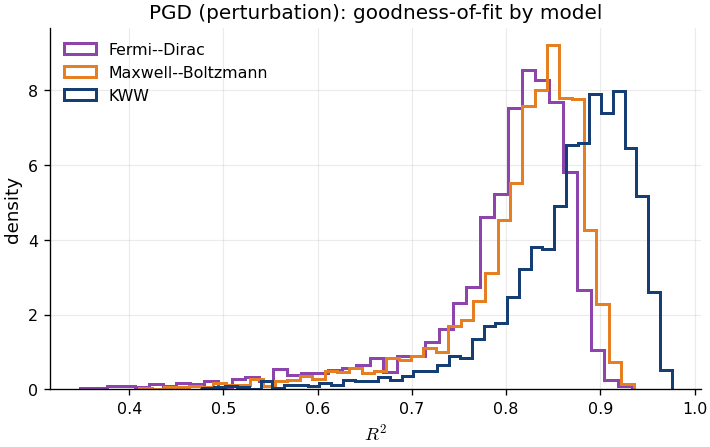

saved figures/dist_dAIC_kww_mb_PGD.pdf


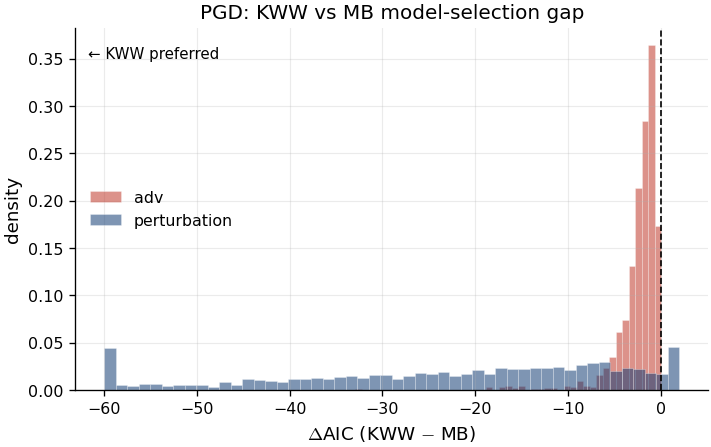

In [3]:
def plot_param_distribution(attack, param="beta", types=("adv", "perturbation"), bins=40):
    df = _read(P["master"](attack))
    if df is None: return
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for t in types:
        v = pd.to_numeric(df.loc[df["type"] == t, param], errors="coerce").dropna()
        if len(v) == 0: continue
        ax.hist(v, bins=bins, density=True, alpha=0.55,
                color=TYPE_COLORS.get(t, None), label=t, edgecolor="white", linewidth=0.3)
    sym = {"beta": r"$\beta$ (KWW stretching exponent)"}.get(param, param)
    ax.set_xlabel(sym); ax.set_ylabel("density")
    ax.set_title(f"{attack}: distribution of {sym} by type")
    ax.legend(frameon=False)
    fig.tight_layout(); savefig(fig, f"dist_{param}_{attack}"); plt.show()

def plot_r2_distributions(attack, type_="perturbation", bins=40):
    df = _read(P["master"](attack))
    if df is None: return
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    d = df[df["type"] == type_]
    for m in ("fd", "mb", "kww"):
        v = pd.to_numeric(d[f"R2_{m}"], errors="coerce").dropna()
        ax.hist(v, bins=bins, density=True, histtype="step", linewidth=1.8,
                color=MODEL_COLORS[m], label=MODEL_LABEL[m])
    ax.set_xlabel(r"$R^2$"); ax.set_ylabel("density")
    ax.set_title(f"{attack} ({type_}): goodness-of-fit by model")
    ax.legend(frameon=False)
    fig.tight_layout(); savefig(fig, f"dist_R2_{attack}_{type_}"); plt.show()

def plot_daic_distribution(attack, types=("adv", "perturbation"), bins=50, clip=(-60, 30)):
    df = _read(P["master"](attack))
    if df is None: return
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    for t in types:
        d = df[df["type"] == t]
        v = (pd.to_numeric(d["AIC_kww"], errors="coerce")
             - pd.to_numeric(d["AIC_mb"], errors="coerce")).dropna().clip(*clip)
        ax.hist(v, bins=bins, density=True, alpha=0.55, color=TYPE_COLORS.get(t),
                label=t, edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.set_xlabel(r"$\Delta$AIC (KWW $-$ MB)"); ax.set_ylabel("density")
    ax.set_title(f"{attack}: KWW vs MB model-selection gap")
    ax.text(0.02, 0.95, "← KWW preferred", transform=ax.transAxes, va="top", fontsize=9)
    ax.legend(frameon=False)
    fig.tight_layout(); savefig(fig, f"dist_dAIC_kww_mb_{attack}"); plt.show()

for a in ATTACKS:
    plot_param_distribution(a, "beta")
    plot_r2_distributions(a, "perturbation")
    plot_daic_distribution(a)

## 3. Radial occupation profiles

The median radial occupation profile in energy space $E=k^2$ (with a 25–75%
band), overlaid with the three model laws evaluated at the **median fitted
parameters**. Uses the compact `.npz` written by the generation stage, so no
attack is re-run.

saved figures/radial_BIM_perturbation_eps8.pdf


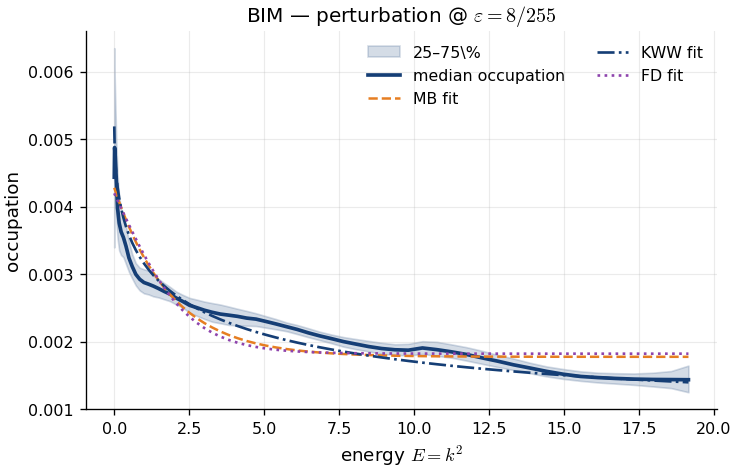

saved figures/radial_evolution_BIM_perturbation.pdf


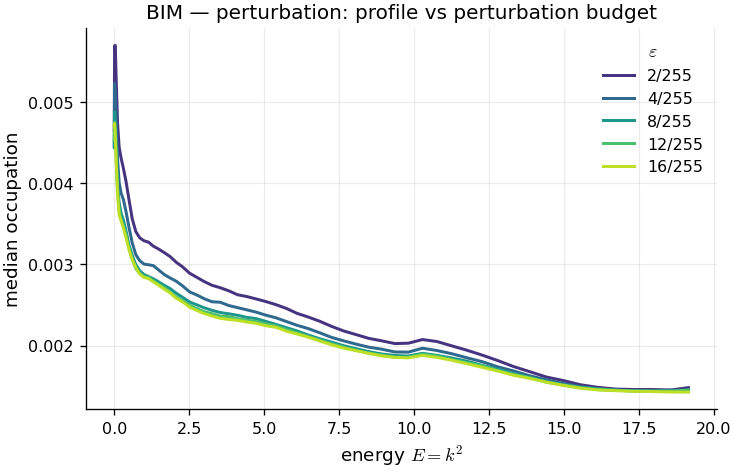

saved figures/radial_PGD_perturbation_eps8.pdf


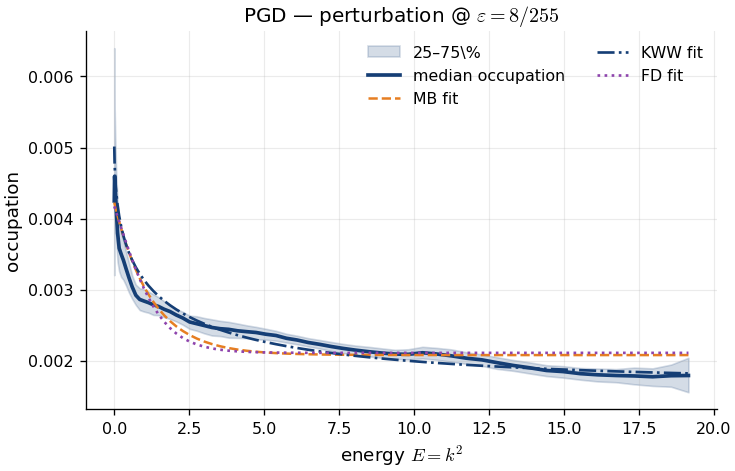

saved figures/radial_evolution_PGD_perturbation.pdf


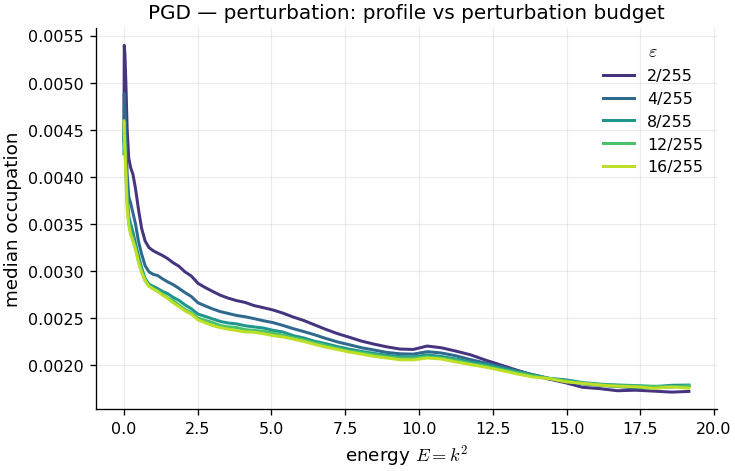

In [4]:
def _load_radial(attack):
    path = P["radial"](attack)
    if not Path(path).exists():
        print(f"  [skip] missing: {path}"); return None
    z = np.load(path, allow_pickle=True)
    k = np.asarray(z["k_ref"], dtype=float)
    idx = {k_: i for i, k_ in enumerate(z["keys"])}
    med = np.asarray(z["median"], dtype=float)
    p25 = np.asarray(z["p25"], dtype=float)
    p75 = np.asarray(z["p75"], dtype=float)
    return {"k": k, "idx": idx, "median": med, "p25": p25, "p75": p75}

def _median_params(attack, type_, eps_pix):
    df = _read(P["master"](attack))
    if df is None: return None
    d = df[(df["type"] == type_) & (np.isclose(df["eps_pix"], eps_pix))]
    if len(d) == 0: return None
    med = d.median(numeric_only=True)
    return {
        "fd":  [med.get(c, np.nan) for c in ("mu_fd", "T_fd", "A_fd", "C_fd")],
        "mb":  [med.get(c, np.nan) for c in ("T_mb", "A_mb", "C_mb")],
        "kww": [med.get(c, np.nan) for c in ("T_kww", "beta", "A_kww", "C_kww")],
    }

def plot_radial_profile(attack, type_="perturbation", eps=8, overlay_fits=True):
    R = _load_radial(attack)
    if R is None: return
    eps_pix = eps / 255.0
    key = f"{attack}|{type_}|{eps_pix}"
    if key not in R["idx"]:
        print(f"  [skip] no curve for {key}"); return
    i = R["idx"][key]
    k = R["k"]; E = k ** 2
    med, lo, hi = R["median"][i], R["p25"][i], R["p75"][i]

    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    ax.fill_between(E, lo, hi, color=TYPE_COLORS.get(type_, "#153E75"), alpha=0.18,
                    label="25–75\\%" if not USE_TEX else r"25--75\%")
    ax.plot(E, med, color=TYPE_COLORS.get(type_, "#153E75"), lw=2.2, label="median occupation")

    if overlay_fits:
        pars = _median_params(attack, type_, eps_pix)
        if pars is not None:
            if np.all(np.isfinite(pars["mb"])):
                ax.plot(E, maxwell_boltzmann_E(E, *pars["mb"]), color=MODEL_COLORS["mb"],
                        ls="--", lw=1.5, label="MB fit")
            if np.all(np.isfinite(pars["kww"])):
                ax.plot(E, kww_glass_E(E, *pars["kww"]), color=MODEL_COLORS["kww"],
                        ls="-.", lw=1.6, label="KWW fit")
            if np.all(np.isfinite(pars["fd"])):
                ax.plot(E, fermi_dirac_E(E, *pars["fd"]), color=MODEL_COLORS["fd"],
                        ls=":", lw=1.6, label="FD fit")
    ax.set_xlabel(r"energy $E=k^2$"); ax.set_ylabel("occupation")
    ax.set_title(f"{attack} — {type_} @ $\\varepsilon={eps}/255$")
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout(); savefig(fig, f"radial_{attack}_{type_}_eps{eps}"); plt.show()

def plot_radial_evolution(attack, type_="perturbation"):
    R = _load_radial(attack)
    if R is None: return
    fig, ax = plt.subplots(figsize=(6.4, 4.2))
    cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(EPS_VALUES)))
    plotted = False
    for c, e in zip(cmap, EPS_VALUES):
        key = f"{attack}|{type_}|{e/255.0}"
        if key not in R["idx"]: continue
        i = R["idx"][key]; E = R["k"] ** 2
        ax.plot(E, R["median"][i], color=c, lw=1.8, label=eps_label(e/255.0)); plotted = True
    if not plotted:
        plt.close(fig); print("  [skip] no curves"); return
    ax.set_xlabel(r"energy $E=k^2$"); ax.set_ylabel("median occupation")
    ax.set_title(f"{attack} — {type_}: profile vs perturbation budget")
    ax.legend(frameon=False, title=r"$\varepsilon$")
    fig.tight_layout(); savefig(fig, f"radial_evolution_{attack}_{type_}"); plt.show()

for a in ATTACKS:
    plot_radial_profile(a, "perturbation", eps=8)
    plot_radial_evolution(a, "perturbation")

## 4. Test A — descriptor evolution with budget

Parameter median vs $\varepsilon$ with bootstrap CI, image-wise Spearman $\rho$,
and the transition-score ranking.

saved figures/A_BIM_adv_beta_vs_eps.pdf


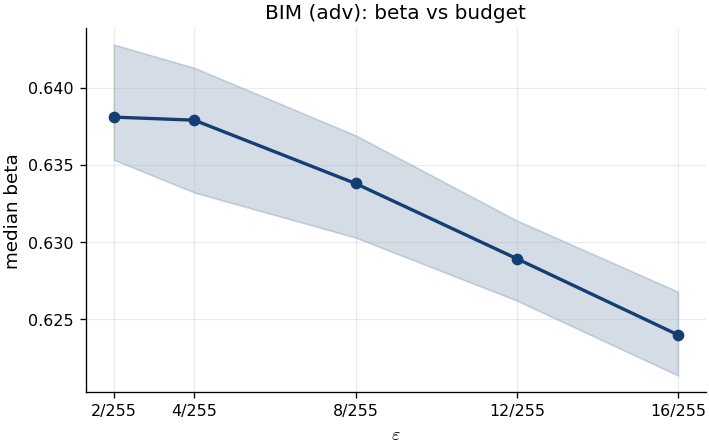

saved figures/A_BIM_adv_imagewise_rho.pdf


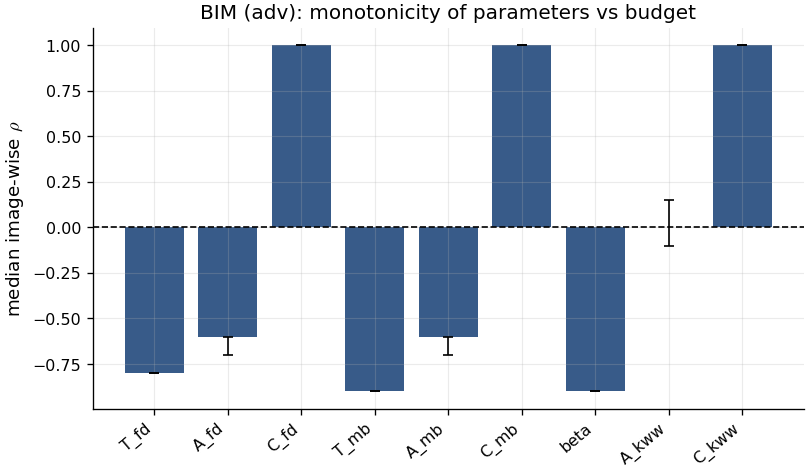

saved figures/A_BIM_adv_transition_scores.pdf


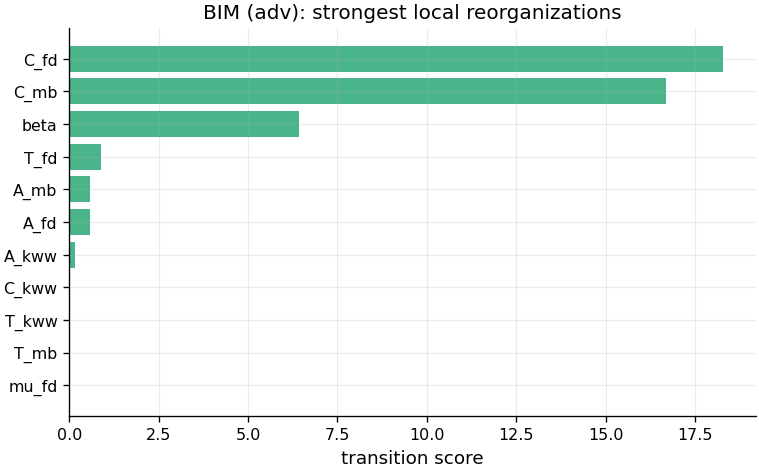

saved figures/A_PGD_adv_beta_vs_eps.pdf


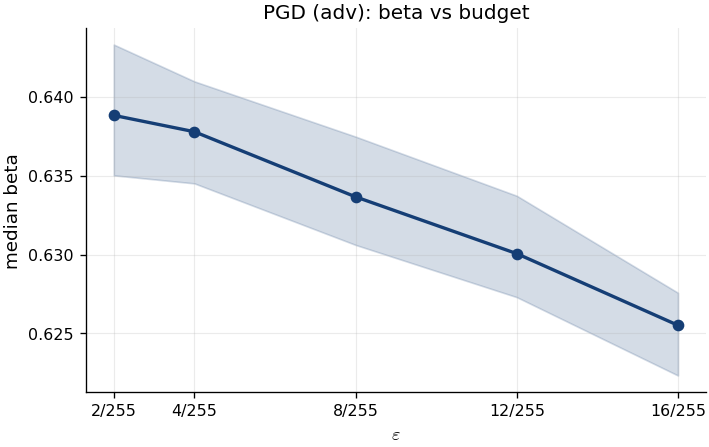

saved figures/A_PGD_adv_imagewise_rho.pdf


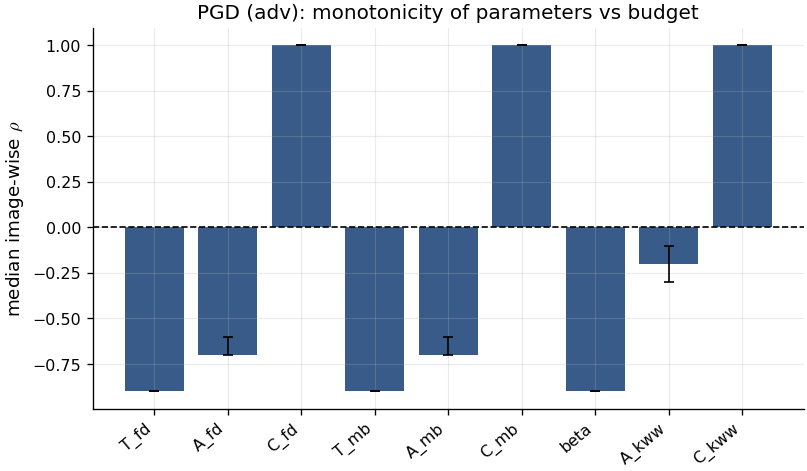

saved figures/A_PGD_adv_transition_scores.pdf


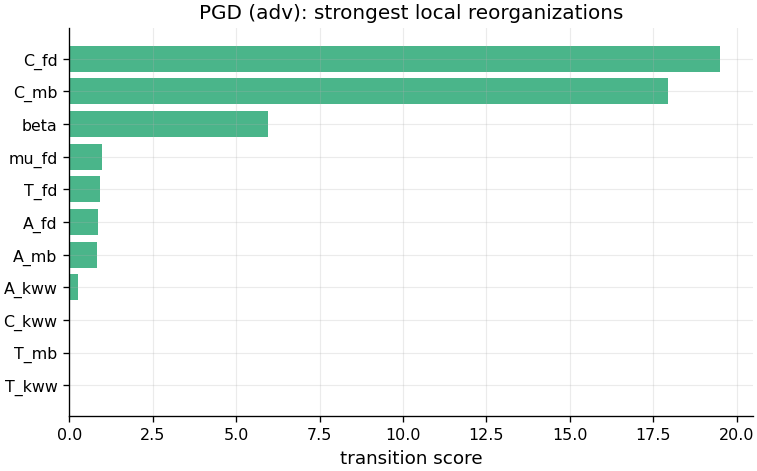

In [5]:
def plot_param_vs_eps(attack, param="beta", tf="adv"):
    df = _read(P["A"](attack, tf, "summary_image_level"))
    if df is None: return
    d = df[df["param"] == param].sort_values("eps_pix")
    if len(d) == 0:
        print(f"  [skip] {attack}/{tf}: no rows for '{param}'"); return
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    x = d["eps_pix"].to_numpy()
    ax.plot(x, d["median"], marker="o", color="#153E75", lw=2)
    ax.fill_between(x, d["ci_low"], d["ci_high"], color="#153E75", alpha=0.18)
    ax.set_xticks(x); ax.set_xticklabels(eps_ticks(x))
    ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel(f"median {param}")
    ax.set_title(f"{attack} ({tf}): {param} vs budget")
    fig.tight_layout(); savefig(fig, f"A_{attack}_{tf}_{param}_vs_eps"); plt.show()

def plot_imagewise_rho(attack, tf="adv"):
    df = _read(P["A"](attack, tf, "monotonicity_image_level"))
    if df is None or "rho_median" not in df.columns: return
    d = df.dropna(subset=["rho_median"]).copy()
    if len(d) == 0:
        print(f"  [skip] {attack}/{tf}: no monotonicity rows (need >=3 eps per image)"); return
    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    x = np.arange(len(d))
    lo = d["rho_median"] - d["rho_ci_low"]; hi = d["rho_ci_high"] - d["rho_median"]
    ax.bar(x, d["rho_median"], color="#153E75", alpha=0.85)
    ax.errorbar(x, d["rho_median"], yerr=[lo, hi], fmt="none", ecolor="k", capsize=3, lw=1)
    ax.axhline(0, color="k", ls="--", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(d["param"], rotation=40, ha="right")
    ax.set_ylabel(r"median image-wise $\rho$")
    ax.set_title(f"{attack} ({tf}): monotonicity of parameters vs budget")
    fig.tight_layout(); savefig(fig, f"A_{attack}_{tf}_imagewise_rho"); plt.show()

def plot_transition_scores(attack, tf="adv"):
    df = _read(P["A"](attack, tf, "transition_scores_image_level"))
    if df is None or "transition_score" not in df.columns: return
    d = df.dropna(subset=["transition_score"]).sort_values("transition_score")
    if len(d) == 0:
        print(f"  [skip] {attack}/{tf}: all transition scores are NaN "
              f"(need >=test_a_min_pairs images per adjacent-eps pair; "
              f"raise n_images or lower test_a_min_pairs for small tests)"); return
    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    ax.barh(d["param"], d["transition_score"], color="#2AA876", alpha=0.85)
    ax.set_xlabel("transition score"); ax.set_title(f"{attack} ({tf}): strongest local reorganizations")
    fig.tight_layout(); savefig(fig, f"A_{attack}_{tf}_transition_scores"); plt.show()

for a in ATTACKS:
    plot_param_vs_eps(a, "beta", "adv")
    plot_imagewise_rho(a, "adv")
    plot_transition_scores(a, "adv")

## 5. Test B — model validation / overfitting

Median $R^2$ per model, the KWW–MB selection gap, win rates and the
consistency / overfit breakdown.

saved figures/B_BIM_perturbation_median_r2.pdf


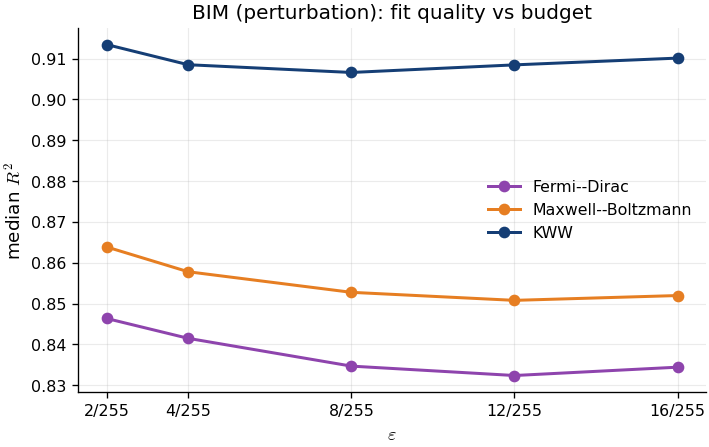

saved figures/B_BIM_perturbation_delta_selection.pdf


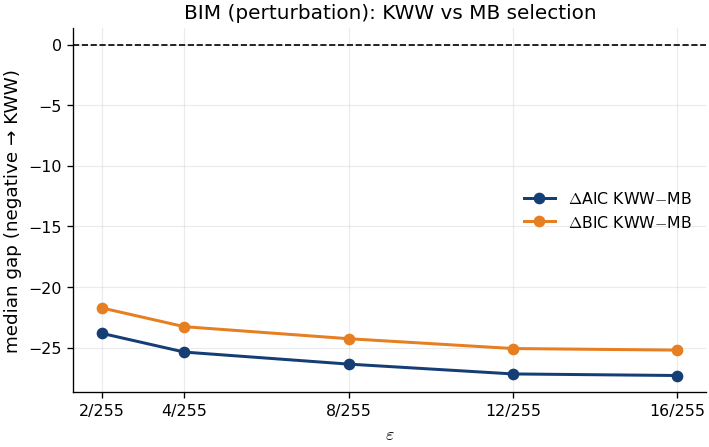

saved figures/B_BIM_perturbation_win_rates.pdf


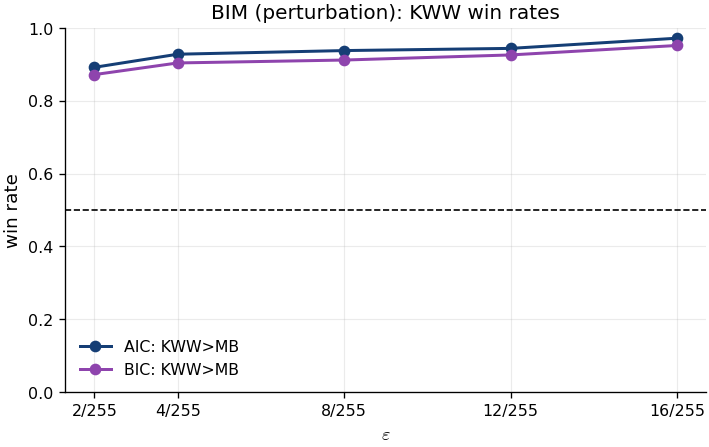

saved figures/B_BIM_perturbation_kww_mb_consistency.pdf


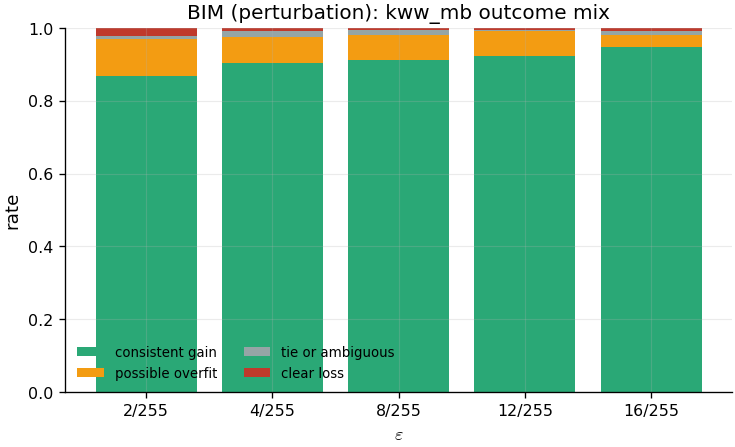

saved figures/B_PGD_perturbation_median_r2.pdf


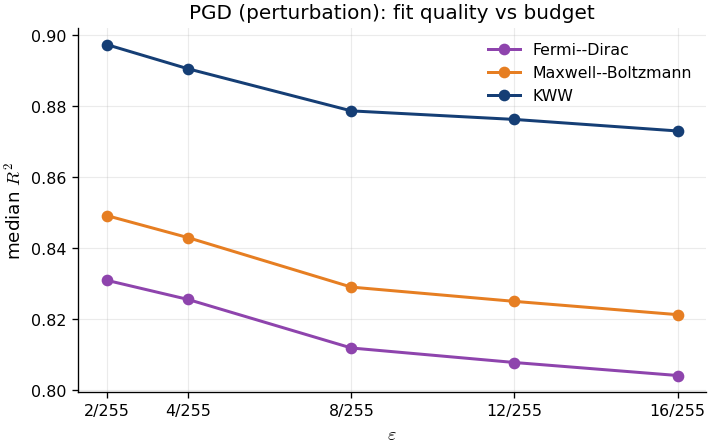

saved figures/B_PGD_perturbation_delta_selection.pdf


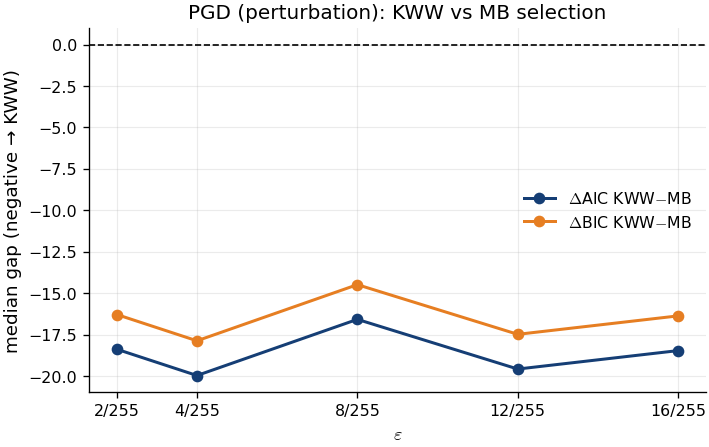

saved figures/B_PGD_perturbation_win_rates.pdf


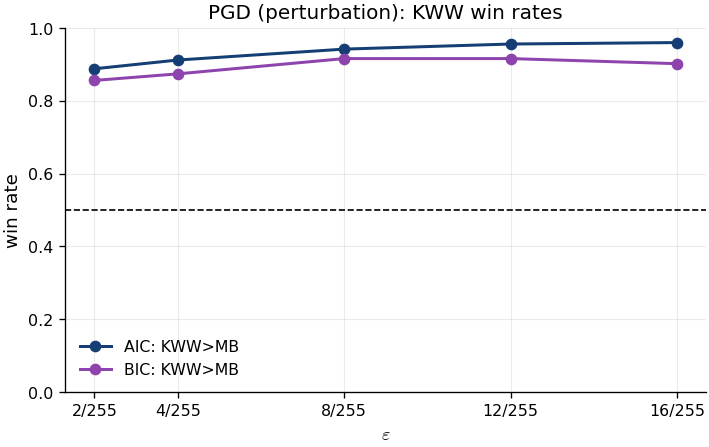

saved figures/B_PGD_perturbation_kww_mb_consistency.pdf


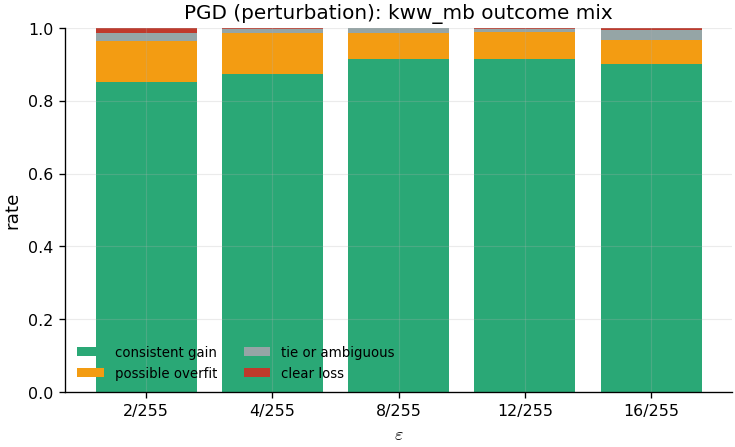

In [6]:
def _bsub(attack, type_):
    df = _read(P["B_sum"])
    if df is None: return None
    return df[(df["attack"] == attack) & (df["type"] == type_)].sort_values("eps_pix")

def plot_median_r2_vs_eps(attack, type_="perturbation"):
    d = _bsub(attack, type_)
    if d is None or len(d) == 0: return
    fig, ax = plt.subplots(figsize=(6.2, 4.0)); x = d["eps_pix"].to_numpy()
    for m in ("fd", "mb", "kww"):
        col = f"R2_{m}_median"
        if col in d: ax.plot(x, d[col], marker="o", color=MODEL_COLORS[m], label=MODEL_LABEL[m])
    ax.set_xticks(x); ax.set_xticklabels(eps_ticks(x))
    ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel(r"median $R^2$")
    ax.set_title(f"{attack} ({type_}): fit quality vs budget"); ax.legend(frameon=False)
    fig.tight_layout(); savefig(fig, f"B_{attack}_{type_}_median_r2"); plt.show()

def plot_delta_selection_vs_eps(attack, type_="perturbation"):
    d = _bsub(attack, type_)
    if d is None or len(d) == 0: return
    fig, ax = plt.subplots(figsize=(6.2, 4.0)); x = d["eps_pix"].to_numpy()
    for col, lab, c in [("dAIC_kww_mb_median", r"$\Delta$AIC KWW$-$MB", "#153E75"),
                        ("dBIC_kww_mb_median", r"$\Delta$BIC KWW$-$MB", "#E67E22")]:
        if col in d: ax.plot(x, d[col], marker="o", color=c, label=lab)
    ax.axhline(0, color="k", ls="--", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(eps_ticks(x))
    ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel("median gap (negative → KWW)")
    ax.set_title(f"{attack} ({type_}): KWW vs MB selection"); ax.legend(frameon=False)
    fig.tight_layout(); savefig(fig, f"B_{attack}_{type_}_delta_selection"); plt.show()

def plot_win_rates(attack, type_="perturbation"):
    d = _bsub(attack, type_)
    if d is None or len(d) == 0: return
    fig, ax = plt.subplots(figsize=(6.2, 4.0)); x = d["eps_pix"].to_numpy()
    for col, lab, c in [("win_AIC_kww_mb", "AIC: KWW>MB", "#153E75"),
                        ("win_BIC_kww_mb", "BIC: KWW>MB", "#8E44AD")]:
        if col in d: ax.plot(x, d[col], marker="o", color=c, label=lab)
    ax.axhline(0.5, color="k", ls="--", lw=1)
    ax.set_ylim(0, 1); ax.set_xticks(x); ax.set_xticklabels(eps_ticks(x))
    ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel("win rate"); ax.set_title(f"{attack} ({type_}): KWW win rates")
    ax.legend(frameon=False)
    fig.tight_layout(); savefig(fig, f"B_{attack}_{type_}_win_rates"); plt.show()

def plot_consistency_stacked(attack, type_="perturbation", pair="kww_mb"):
    df = _read(P["B_cons"])
    if df is None: return
    d = df[(df["attack"] == attack) & (df["type"] == type_) & (df["pair"] == pair)].sort_values("eps_pix")
    if len(d) == 0: print(f"  [skip] no {pair}"); return
    cats = ["consistent_gain", "possible_overfit", "tie_or_ambiguous", "clear_loss"]
    colors = ["#2AA876", "#F39C12", "#95A5A6", "#C0392B"]
    fig, ax = plt.subplots(figsize=(6.4, 4.0)); x = np.arange(len(d)); bottom = np.zeros(len(d))
    for cat, c in zip(cats, colors):
        col = f"{cat}_rate"
        if col not in d: continue
        ax.bar(x, d[col], bottom=bottom, color=c, label=cat.replace("_", " "))
        bottom += d[col].to_numpy()
    ax.set_xticks(x); ax.set_xticklabels(eps_ticks(d["eps_pix"]))
    ax.set_ylim(0, 1); ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel("rate")
    ax.set_title(f"{attack} ({type_}): {pair} outcome mix")
    ax.legend(frameon=False, ncol=2, fontsize=8)
    fig.tight_layout(); savefig(fig, f"B_{attack}_{type_}_{pair}_consistency"); plt.show()

for a in ATTACKS:
    plot_median_r2_vs_eps(a, "perturbation")
    plot_delta_selection_vs_eps(a, "perturbation")
    plot_win_rates(a, "perturbation")
    plot_consistency_stacked(a, "perturbation", "kww_mb")

## 6. Test C — anisotropy-index validation

Upgraded, vectorized versions of the AI trend, Cliff's-delta, paired-shuffle and
monotonicity figures.

saved figures/C_BIM_ai_trend.pdf


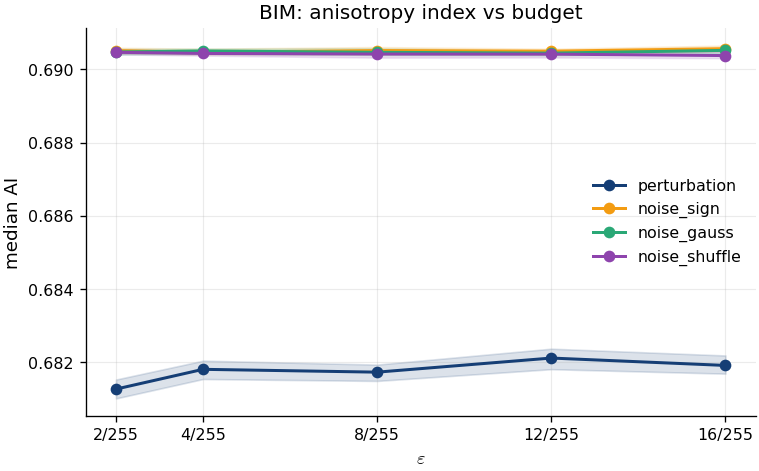

saved figures/C_BIM_cliffs.pdf


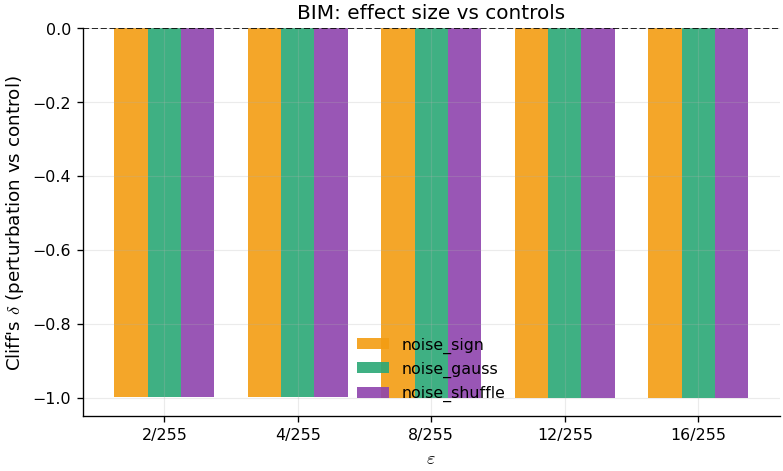

saved figures/C_BIM_paired_shuffle.pdf


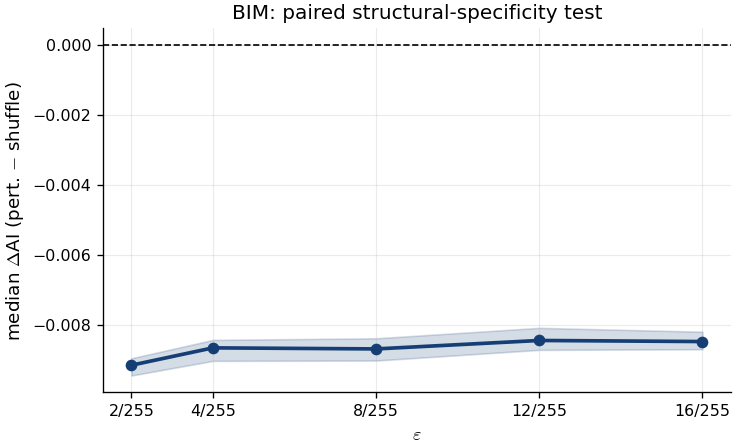

saved figures/C_BIM_monotonicity.pdf


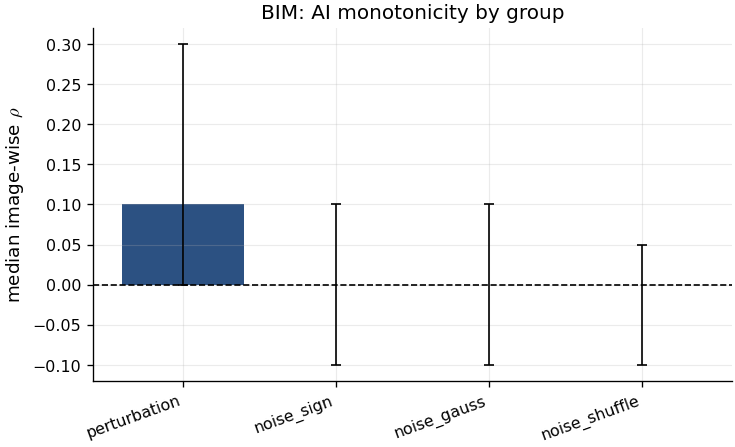

saved figures/C_PGD_ai_trend.pdf


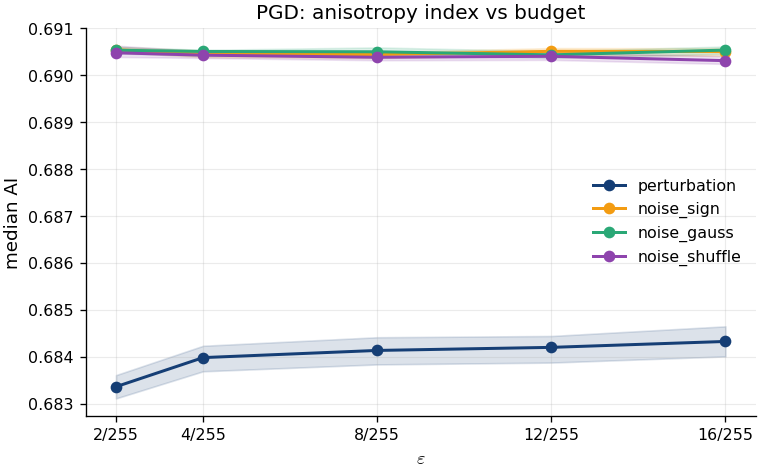

saved figures/C_PGD_cliffs.pdf


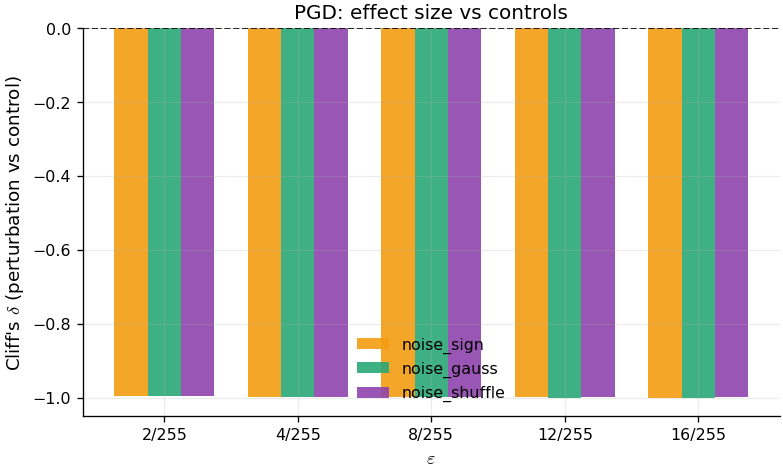

saved figures/C_PGD_paired_shuffle.pdf


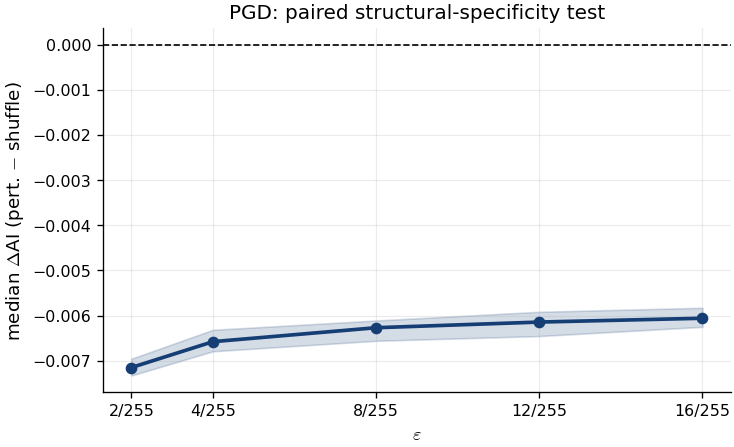

saved figures/C_PGD_monotonicity.pdf


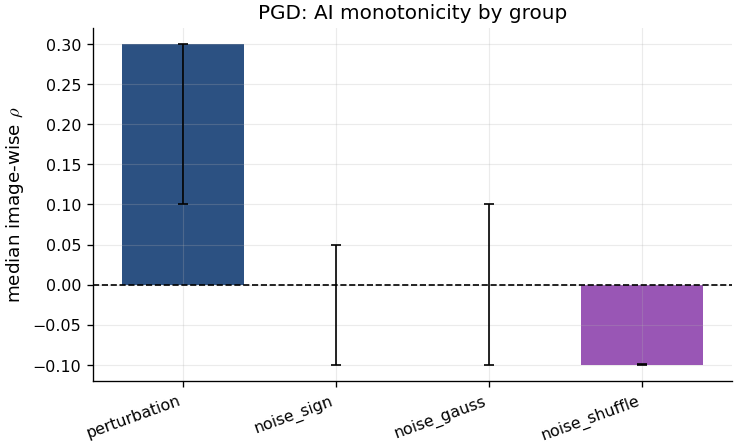

In [7]:
def plot_ai_trend(attack):
    df = _read(P["C_sum"](attack))
    if df is None: return
    order = ["perturbation", "noise_sign", "noise_gauss", "noise_shuffle"]
    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    for g in order:
        s = df[df["group"] == g].sort_values("eps_pix")
        if len(s) == 0: continue
        x = s["eps_pix"].to_numpy()
        ax.plot(x, s["median_AI"], marker="o", color=GROUP_COLORS[g], label=g)
        ax.fill_between(x, s["ci_low_AI"], s["ci_high_AI"], color=GROUP_COLORS[g], alpha=0.15)
    xs = np.sort(df["eps_pix"].unique())
    ax.set_xticks(xs); ax.set_xticklabels(eps_ticks(xs))
    ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel("median AI")
    ax.set_title(f"{attack}: anisotropy index vs budget"); ax.legend(frameon=False)
    fig.tight_layout(); savefig(fig, f"C_{attack}_ai_trend"); plt.show()

def plot_cliffs(attack):
    df = _read(P["C_cmp"](attack))
    if df is None: return
    ctrls = ["noise_sign", "noise_gauss", "noise_shuffle"]
    xs = np.sort(df["eps_pix"].unique()); x = np.arange(len(xs)); w = 0.25
    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    for ctrl, off in zip(ctrls, (-w, 0, w)):
        s = df[df["control_group"] == ctrl].sort_values("eps_pix")
        ax.bar(x + off, s["cliffs_delta"], width=w, color=GROUP_COLORS[ctrl], label=ctrl, alpha=0.9)
    ax.axhline(0, color="k", ls="--", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(eps_ticks(xs))
    ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel("Cliff's $\\delta$ (perturbation vs control)")
    ax.set_title(f"{attack}: effect size vs controls"); ax.legend(frameon=False)
    fig.tight_layout(); savefig(fig, f"C_{attack}_cliffs"); plt.show()

def plot_paired_shuffle(attack):
    df = _read(P["C_pair"](attack))
    if df is None or "delta_median_paired" not in df.columns: return
    d = df.dropna(subset=["delta_median_paired"]).sort_values("eps_pix")
    fig, ax = plt.subplots(figsize=(6.4, 4.0)); x = d["eps_pix"].to_numpy()
    ax.plot(x, d["delta_median_paired"], marker="o", color="#153E75", lw=2.2)
    ax.fill_between(x, d["delta_ci_low"], d["delta_ci_high"], color="#153E75", alpha=0.18)
    ax.axhline(0, color="k", ls="--", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(eps_ticks(x))
    ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel(r"median $\Delta$AI (pert. $-$ shuffle)")
    ax.set_title(f"{attack}: paired structural-specificity test")
    fig.tight_layout(); savefig(fig, f"C_{attack}_paired_shuffle"); plt.show()

def plot_ai_monotonicity(attack):
    df = _read(P["C_mono"](attack))
    if df is None or "rho_median" not in df.columns: return
    order = ["perturbation", "noise_sign", "noise_gauss", "noise_shuffle"]
    d = df.set_index("group").reindex(order).dropna(subset=["rho_median"]).reset_index()
    fig, ax = plt.subplots(figsize=(6.4, 4.0)); x = np.arange(len(d))
    lo = d["rho_median"] - d["rho_ci_low"]; hi = d["rho_ci_high"] - d["rho_median"]
    ax.bar(x, d["rho_median"], color=[GROUP_COLORS[g] for g in d["group"]], alpha=0.9)
    ax.errorbar(x, d["rho_median"], yerr=[lo, hi], fmt="none", ecolor="k", capsize=3, lw=1)
    ax.axhline(0, color="k", ls="--", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(d["group"], rotation=20, ha="right")
    ax.set_ylabel(r"median image-wise $\rho$")
    ax.set_title(f"{attack}: AI monotonicity by group")
    fig.tight_layout(); savefig(fig, f"C_{attack}_monotonicity"); plt.show()

for a in ATTACKS:
    plot_ai_trend(a); plot_cliffs(a); plot_paired_shuffle(a); plot_ai_monotonicity(a)

## 7. Test D — saturation / clipping sanity

Saturation metrics vs budget and the clip-vs-raw_cap profile-mode comparison
(does removing the hard clip change model selection?).

saved figures/D_occ_raw_p99_clip.pdf


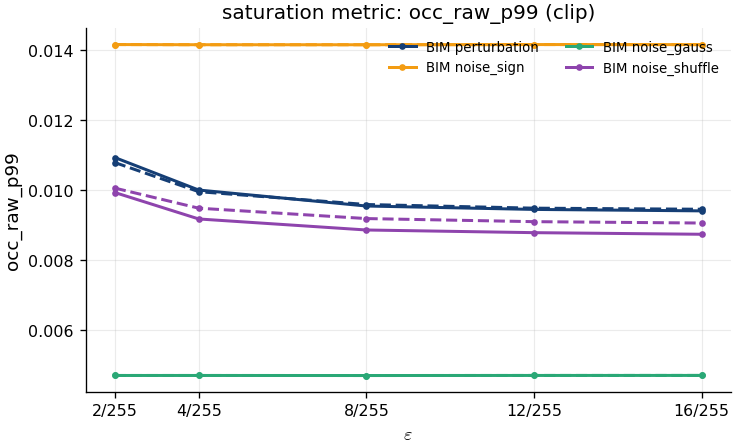

saved figures/D_clip_frac_clip.pdf


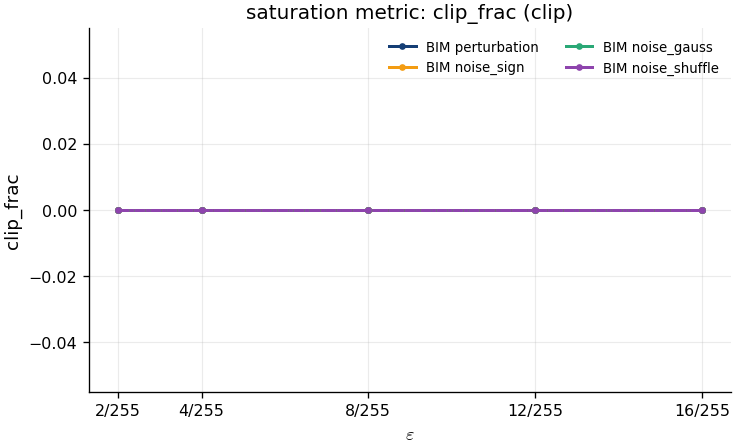

saved figures/D_profile_mode_dAIC_kww_mb_BIM_perturbation.pdf


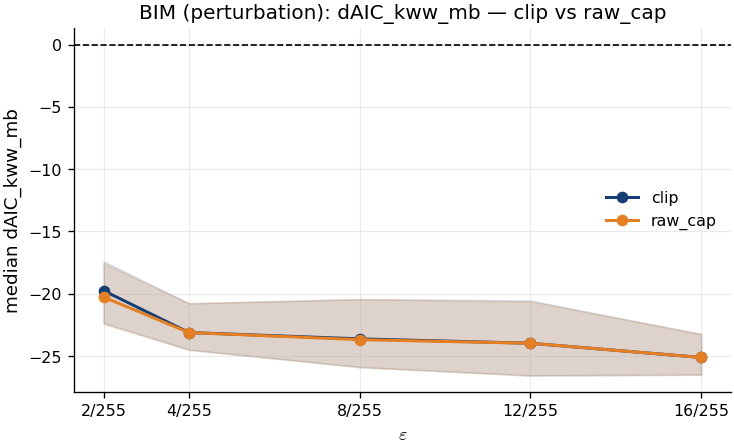

In [8]:
def plot_saturation_metric(metric="occ_raw_p99", pmode="clip"):
    df = _read(P["D_sum"])
    if df is None: return
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    d = df[(df["metric"] == metric) & (df["profile_mode"] == pmode)]
    for attack in ATTACKS:
        for typ, c in [("perturbation", "#153E75"), ("noise_sign", "#F39C12"),
                       ("noise_gauss", "#2AA876"), ("noise_shuffle", "#8E44AD")]:
            s = d[(d["attack"] == attack) & (d["type"] == typ)].sort_values("eps_pix")
            if len(s) == 0: continue
            ls = "-" if attack == "BIM" else "--"
            ax.plot(s["eps_pix"], s["median"], marker="o", ms=3, ls=ls, color=c,
                    label=f"{attack} {typ}" if attack == "BIM" else None)
    xs = np.sort(d["eps_pix"].unique())
    if len(xs): ax.set_xticks(xs); ax.set_xticklabels(eps_ticks(xs))
    ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel(metric)
    ax.set_title(f"saturation metric: {metric} ({pmode})")
    ax.legend(frameon=False, fontsize=8, ncol=2)
    fig.tight_layout(); savefig(fig, f"D_{metric}_{pmode}"); plt.show()

def plot_profile_mode_compare(metric="dAIC_kww_mb", attack="BIM", type_="perturbation"):
    df = _read(P["D_pm"](metric))
    if df is None: return
    d = df[(df["attack"] == attack) & (df["type"] == type_)]
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    for pmode, c in [("clip", "#153E75"), ("raw_cap", "#E67E22")]:
        s = d[d["profile_mode"] == pmode].sort_values("eps_pix")
        if len(s) == 0: continue
        x = s["eps_pix"].to_numpy()
        ax.plot(x, s["median"], marker="o", color=c, label=pmode)
        ax.fill_between(x, s["ci_low"], s["ci_high"], color=c, alpha=0.15)
    ax.axhline(0, color="k", ls="--", lw=1)
    xs = np.sort(d["eps_pix"].unique())
    if len(xs): ax.set_xticks(xs); ax.set_xticklabels(eps_ticks(xs))
    ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel(f"median {metric}")
    ax.set_title(f"{attack} ({type_}): {metric} — clip vs raw_cap"); ax.legend(frameon=False)
    fig.tight_layout(); savefig(fig, f"D_profile_mode_{metric}_{attack}_{type_}"); plt.show()

plot_saturation_metric("occ_raw_p99", "clip")
plot_saturation_metric("clip_frac", "clip")
plot_profile_mode_compare("dAIC_kww_mb", "BIM", "perturbation")

---
All figures are in `plots/figures/` as `.pdf` + `.svg`. To regenerate after a new
run, just restart-and-run-all. Point `RESULTS_DIR`, `N_IMAGES` and `ATTACKS` at
the top to whatever your `config.yaml` used.